In [19]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [20]:
df = pd.read_csv("/Users/matteoarutadm/lavoro/digital_mens/SpaceRiskIntelligence/cambiamenti_climatici/claudia/dataset_log1p.csv")

In [21]:
X = df.drop(columns=[
    "fire_next_7d",               
    "fire_count_next_7d",         
    "target_horizon_complete_7d",
    "date",
    "segment_start",
    "segment_end"
])
y = df["fire_count_next_7d"]

In [22]:
import numpy as np

y = np.log1p(df["fire_count_next_7d"])

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

In [25]:
X_train.dtypes

segment_id                   int64
lat_cell                   float64
lon_cell                   float64
detection_count            float64
daily_frp_sum              float64
daily_frp_max              float64
daily_frp_mean             float64
active_fire_day              int64
detection_lag_1d           float64
detection_lag_3d           float64
detection_lag_7d           float64
detection_lag_14d          float64
detection_sum_last_3d      float64
active_days_last_3d        float64
frp_sum_last_3d            float64
detection_sum_last_7d      float64
active_days_last_7d        float64
frp_sum_last_7d            float64
detection_sum_last_14d     float64
active_days_last_14d       float64
frp_sum_last_14d           float64
detection_sum_last_30d     float64
active_days_last_30d       float64
frp_sum_last_30d           float64
frp_mean_active_last_7d    float64
day_of_year                  int64
sin_doy                    float64
cos_doy                    float64
dtype: object

In [26]:
model.fit(X_train, y_train)
y_out = model.predict(X_test)

In [27]:
mse = mean_squared_error(y_test, y_out)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_out)
r2 = r2_score(y_test, y_out)

In [28]:
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")  

Mean Squared Error (MSE): 0.3091289141069299
Root Mean Squared Error (RMSE): 0.555993627757486
Mean Absolute Error (MAE): 0.35509041008639525
R-squared (R2): 0.7440710729281421


In [29]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(15))

active_days_last_14d       0.288757
lat_cell                   0.080170
lon_cell                   0.077584
detection_sum_last_30d     0.057527
sin_doy                    0.047321
detection_count            0.047308
frp_sum_last_30d           0.041450
cos_doy                    0.038965
frp_sum_last_14d           0.035374
frp_mean_active_last_7d    0.031270
active_days_last_30d       0.030151
frp_sum_last_7d            0.028525
detection_sum_last_7d      0.027044
daily_frp_sum              0.025083
detection_sum_last_14d     0.023787
dtype: float64


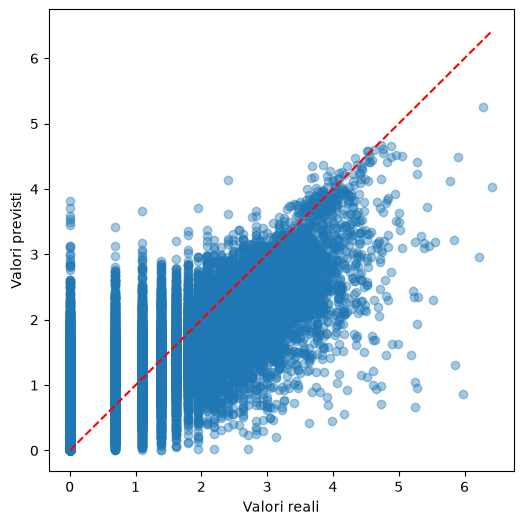

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_out, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.xlabel("Valori reali")
plt.ylabel("Valori previsti")
plt.show()

In [31]:
df["fire_count_next_7d"].describe()

count    194833.000000
mean          4.471568
std          11.886103
min           0.000000
25%           0.000000
50%           1.000000
75%           4.000000
max         741.000000
Name: fire_count_next_7d, dtype: float64

<Axes: >

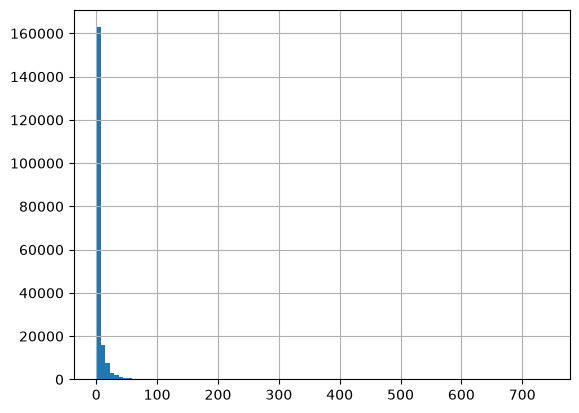

In [32]:
df["fire_count_next_7d"].hist(bins=100)

In [33]:
y_pred_log = model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2): {r2}")

Mean Absolute Error (MAE): 2.6089701436256387
Root Mean Squared Error (RMSE): 9.816741467716911
R-squared (R2): 0.38941491897448444


# BACKTEST

Feature usate nel backtest:
['segment_id', 'lat_cell', 'lon_cell', 'detection_count', 'daily_frp_sum', 'daily_frp_max', 'daily_frp_mean', 'active_fire_day', 'detection_lag_1d', 'detection_lag_3d', 'detection_lag_7d', 'detection_lag_14d', 'detection_sum_last_3d', 'active_days_last_3d', 'frp_sum_last_3d', 'detection_sum_last_7d', 'active_days_last_7d', 'frp_sum_last_7d', 'detection_sum_last_14d', 'active_days_last_14d', 'frp_sum_last_14d', 'detection_sum_last_30d', 'active_days_last_30d', 'frp_sum_last_30d', 'frp_mean_active_last_7d', 'day_of_year', 'sin_doy', 'cos_doy']
Periodi testati:


,fold,train_end,test_start,test_end
0,1,2025-08-31,2025-09-01,2025-09-21
1,5,2025-09-21,2026-01-25,2026-01-31
2,6,2026-01-31,2026-02-01,2026-02-28
3,7,2026-02-28,2026-03-01,2026-03-31
4,8,2026-03-31,2026-04-01,2026-04-17


,fold,train_start,train_end,test_start,test_end,n_train,n_test,MAE,RMSE,R2
0,1,2025-05-26,2025-08-31,2025-09-01,2025-09-21,91459,26358,4.004096,9.083720,0.313235
1,5,2025-05-26,2025-09-21,2026-01-25,2026-01-31,117817,9146,3.714015,8.985460,0.194120
2,6,2025-05-26,2026-01-31,2026-02-01,2026-02-28,126963,39764,2.650966,5.481686,0.290282
3,7,2025-05-26,2026-02-28,2026-03-01,2026-03-31,166727,19525,1.036196,2.146889,0.024000
4,8,2025-05-26,2026-03-31,2026-04-01,2026-04-17,186252,8581,1.083632,3.012559,0.070056


Metriche medie backtest
MAE     2.497781
RMSE    5.742063
R2      0.178339
dtype: float64


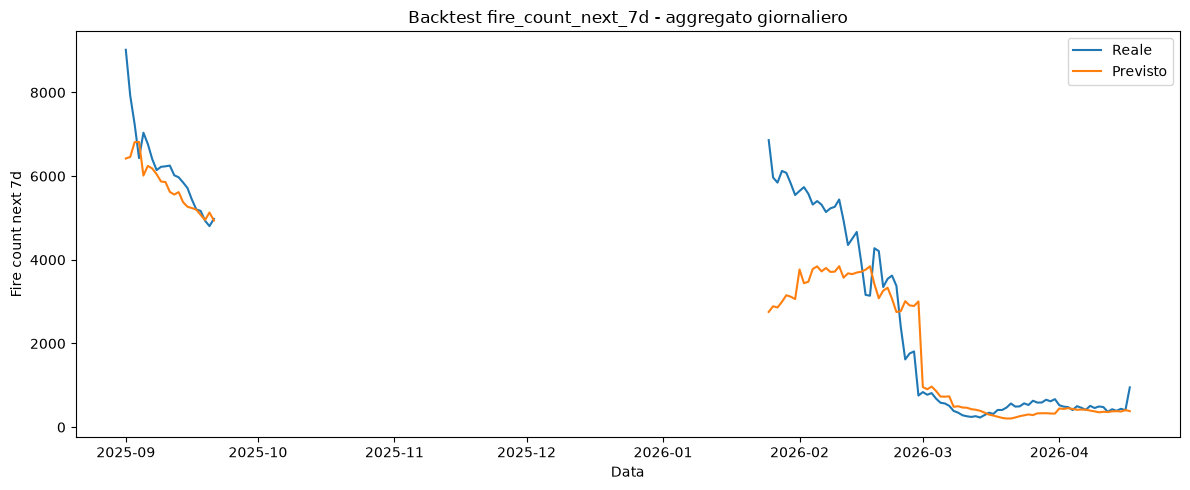

In [ ]:
backtest_df = df.copy()
backtest_df["date"] = pd.to_datetime(backtest_df["date"])
backtest_df = backtest_df.sort_values("date").reset_index(drop=True)

leakage_cols = {
    "fire_count_next_7d",
    "fire_next_7d",
    "target_horizon_complete_7d",
    "date",
    "segment_start",
    "segment_end",
}
feature_cols = [col for col in backtest_df.columns if col not in leakage_cols]

print("Feature usate nel backtest:")
print(feature_cols)

min_train_days = 90
first_test_month = (
    (backtest_df["date"].min() + pd.Timedelta(days=min_train_days))
    .to_period("M")
    .to_timestamp()
    + pd.offsets.MonthBegin(1)
)
last_month = backtest_df["date"].max().to_period("M").to_timestamp()
test_month_starts = pd.date_range(first_test_month, last_month, freq="MS")

backtest_results = []
backtest_predictions = []

for fold, test_start in enumerate(test_month_starts, start=1):
    test_end = test_start + pd.offsets.MonthBegin(1)

    train_mask = backtest_df["date"] < test_start
    test_mask = (backtest_df["date"] >= test_start) & (backtest_df["date"] < test_end)

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        continue

    X_bt_train = backtest_df.loc[train_mask, feature_cols]
    y_bt_train = np.log1p(backtest_df.loc[train_mask, "fire_count_next_7d"])
    X_bt_test = backtest_df.loc[test_mask, feature_cols]
    y_bt_true = backtest_df.loc[test_mask, "fire_count_next_7d"]

    bt_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    bt_model.fit(X_bt_train, y_bt_train)

    y_bt_pred = np.expm1(bt_model.predict(X_bt_test))
    y_bt_pred = np.clip(y_bt_pred, 0, None)

    fold_predictions = pd.DataFrame({
        "fold": fold,
        "date": backtest_df.loc[test_mask, "date"].values,
        "y_true": y_bt_true.values,
        "y_pred": y_bt_pred,
    })
    backtest_predictions.append(fold_predictions)

    backtest_results.append({
        "fold": fold,
        "train_start": backtest_df.loc[train_mask, "date"].min(),
        "train_end": backtest_df.loc[train_mask, "date"].max(),
        "test_start": backtest_df.loc[test_mask, "date"].min(),
        "test_end": backtest_df.loc[test_mask, "date"].max(),
        "n_train": len(X_bt_train),
        "n_test": len(X_bt_test),
        "MAE": mean_absolute_error(y_bt_true, y_bt_pred),
        "RMSE": np.sqrt(mean_squared_error(y_bt_true, y_bt_pred)),
        "R2": r2_score(y_bt_true, y_bt_pred),
    })

backtest_results = pd.DataFrame(backtest_results)
backtest_predictions = pd.concat(backtest_predictions, ignore_index=True)

print("Periodi testati:")
display(backtest_results[["fold", "train_end", "test_start", "test_end"]])

display(backtest_results)

print("Metriche medie backtest")
print(backtest_results[["MAE", "RMSE", "R2"]].mean())

daily_backtest = (
    backtest_predictions
    .groupby("date")[["y_true", "y_pred"]]
    .sum()
)

idx = pd.date_range(
    daily_backtest.index.min(),
    daily_backtest.index.max(),
    freq="D"
)

daily_backtest = daily_backtest.reindex(idx)
daily_backtest.index.name = "date"

plt.figure(figsize=(12, 5))
plt.plot(daily_backtest.index, daily_backtest["y_true"], label="Reale")
plt.plot(daily_backtest.index, daily_backtest["y_pred"], label="Previsto")
plt.title("Backtest fire_count_next_7d - aggregato giornaliero")
plt.xlabel("Data")
plt.ylabel("Fire count next 7d")
plt.legend()
plt.tight_layout()
plt.show()


In [36]:
backtest_df["date"].diff().value_counts().head(10)

date
0 days      194631
1 days         200
126 days         1
Name: count, dtype: int64